# Handling missing values in time series

Missing values are one of the most common problems in real-world time series data. Gaps can appear due to sensor failures, data pipeline outages, holidays, or simply because certain periods were not recorded. Most machine learning estimators cannot handle `NaN` values during training, so dealing with them is a necessary step before building a forecasting model. However, some estimators — such as LightGBM, XGBoost (hist tree method), CatBoost, and scikit-learn's `HistGradientBoostingRegressor` — can natively handle `NaN` values, treating them as a special split direction during tree construction.

Skforecast provides built-in support for training forecasters when the time series (`y`, `series`) or exogenous variables (`exog`) contain interspersed missing values. The key parameter is **`dropna_from_series`**, available in the main forecaster classes. Combined with NaN-tolerant estimators, this gives users full flexibility to choose between dropping incomplete rows or letting the model learn from them.

## Forecasters supporting `dropna_from_series`

| Forecaster | Module | `dropna_from_series` |
|:-----------|:-------|:--------------------:|
| `ForecasterRecursive` | `skforecast.recursive` | ✅ |
| `ForecasterRecursiveMultiSeries` | `skforecast.recursive` | ✅ |
| `ForecasterRecursiveClassifier` | `skforecast.recursive` | ✅ |
| `ForecasterDirect` | `skforecast.direct` | ✅ |
| `ForecasterDirectMultiVariate` | `skforecast.direct` | ✅ |
| `ForecasterRnn` | `skforecast.deep_learning` | ❌ (ignored) |
| `ForecasterStats` | `skforecast.recursive` | ❌ (not applicable) |
| `ForecasterEquivalentDate` | `skforecast.recursive` | ❌ (not applicable) |

## Types of missing values in time series

Before deciding which strategy to use, it is useful to distinguish between different types of missing values:

- **Leading / trailing NaNs**: missing values at the beginning or end of the series. These are usually handled by trimming the series.

- **Interspersed NaNs**: missing values scattered within the recorded period. These are the main focus of this guide.

- **Gaps as missing timestamps**: the DatetimeIndex has no entry for the missing periods. In this case, the index must first be completed (e.g., with `asfreq`) so that the gaps become explicit `NaN` values.

When the forecaster builds its training matrices (lags, window features, exogenous), any `NaN` in the original data can propagate into the rows of `X_train` and `y_train`. The `dropna_from_series` parameter controls what happens next.

## Libraries and data

In [1]:
# Libraries
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lightgbm import LGBMRegressor
from sklearn.ensemble import HistGradientBoostingRegressor

from skforecast.datasets import fetch_dataset
from skforecast.recursive import ForecasterRecursive
from skforecast.model_selection import backtesting_forecaster, TimeSeriesFold
from skforecast.plot import set_dark_theme

In [2]:
# Download data
# ==============================================================================
data = fetch_dataset('bicimad')
data = data.loc['2020-06-01':'2021-06-01'].copy()
data.head(3)

╭──────────────────────────────────── bicimad ─────────────────────────────────────╮
│ Description:                                                                     │
│ This dataset contains the daily users of the bicycle rental service (BiciMad) in │
│ the city of Madrid (Spain) from 2014-06-23 to 2022-09-30.                        │
│                                                                                  │
│ Source:                                                                          │
│ The original data was obtained from: Portal de datos abiertos del Ayuntamiento   │
│ de Madrid https://datos.madrid.es/portal/site/egob                               │
│                                                                                  │
│ URL:                                                                             │
│ https://raw.githubusercontent.com/skforecast/skforecast-                         │
│ datasets/main/data/bicimad_users.csv                                             │
│                                                                                  │
│ Shape: 3022 rows x 1 columns                                                     │
╰──────────────────────────────────────────────────────────────────────────────────╯

,users
date,
2020-06-01,11920
2020-06-02,13238
2020-06-03,13408


In [3]:
# Introduce artificial gaps (missing values)
# ==============================================================================
gaps = [
    ['2020-09-01', '2020-10-10'],
    ['2020-11-08', '2020-12-15'],
]

for gap in gaps:
    data.loc[gap[0]:gap[1]] = np.nan

print(f'Number of NaN values: {data["users"].isna().sum()}')
print(f'Percentage of NaN values: {data["users"].isna().mean():.2%}')

Number of NaN values: 78
Percentage of NaN values: 21.31%


In [4]:
# Split train-test
# ==============================================================================
end_train = '2021-03-01'
data_train = data.loc[:end_train]
data_test  = data.loc[end_train:]

print(
    f'Dates train : {data_train.index.min()} --- {data_train.index.max()}  (n={len(data_train)})'
)
print(
    f'Dates test  : {data_test.index.min()} --- {data_test.index.max()}  (n={len(data_test)})'
)

Dates train : 2020-06-01 00:00:00 --- 2021-03-01 00:00:00  (n=274)
Dates test  : 2021-03-01 00:00:00 --- 2021-06-01 00:00:00  (n=93)


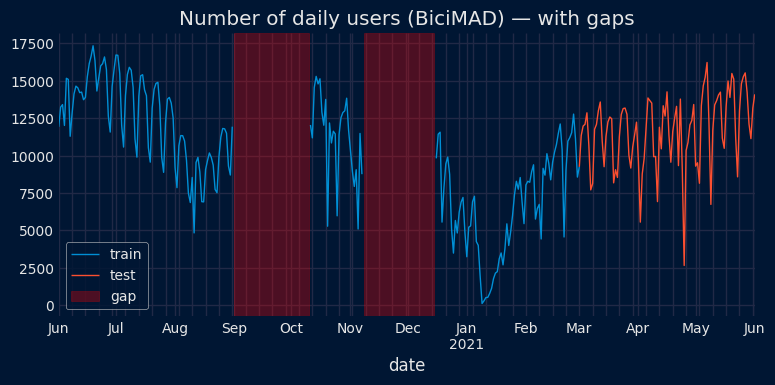

In [5]:
# Plot time series with gaps
# ==============================================================================
set_dark_theme()
fig, ax = plt.subplots(figsize=(8, 3.5))
data_train['users'].plot(ax=ax, label='train', linewidth=1)
data_test['users'].plot(ax=ax, label='test', linewidth=1)

for gap in gaps:
    ax.axvspan(
        pd.to_datetime(gap[0]),
        pd.to_datetime(gap[1]),
        alpha = 0.3,
        color = 'red',
        label = 'gap'
    )

handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys())
ax.set_title('Number of daily users (BiciMAD) — with gaps');

## Option 1: NaN-tolerant estimators

Some estimators can natively handle `NaN` values during training. In this case, you can keep `dropna_from_series=False` (the default) and let the estimator deal with the missing values internally.

Estimators that support `NaN` values include:

- **LightGBM** (`LGBMRegressor`, `LGBMClassifier`)
- **CatBoost** (`CatBoostRegressor`, `CatBoostClassifier`)
- **HistGradientBoosting** (`HistGradientBoostingRegressor`, `HistGradientBoostingClassifier`)
- **XGBoost** (`XGBRegressor`, `XGBClassifier`) when using the `hist` tree method.

**Pros:**

- No training samples are lost, all rows are used during fitting.
- No imputation needed.
- The estimator learns to handle the missingness pattern.

**Cons:**

- Only works with estimators that support `NaN` values.
- The model implicitly treats `NaN` as a special split value, which may not always be optimal.

<div class="admonition note" name="html-admonition" style="background: rgba(0,184,212,.1); padding-top: 0px; padding-bottom: 6px; border-radius: 8px; border-left: 8px solid #00b8d4; border-color: #00b8d4; padding-left: 10px; padding-right: 10px;">

<p class="title">
    <i style="font-size: 18px; color:#00b8d4;"></i>
    <b style="color: #00b8d4;">✏️ Note</b>
</p>

When <code>dropna_from_series=False</code> and the training matrices contain NaN values, skforecast will issue a <code>MissingValuesWarning</code> to inform the user. This warning can be safely ignored by setting <code>suppress_warnings=True</code> when using an estimator that supports NaN values.

</div>

In [6]:
# Option 1a: LGBMRegressor (NaN-tolerant) with dropna_from_series=False
# ==============================================================================
forecaster = ForecasterRecursive(
                 estimator          = LGBMRegressor(random_state=123, verbose=-1),
                 lags               = 14,
                 dropna_from_series = False,
             )

forecaster.fit(y=data_train['users'], suppress_warnings=True)

In [7]:
# Backtesting
# ==============================================================================
cv = TimeSeriesFold(
         steps              = 7,
         initial_train_size = len(data_train),
         refit              = False,
         fixed_train_size   = False,
     )

metric_lgbm, predictions_lgbm = backtesting_forecaster(
                                    forecaster        = forecaster,
                                    y                 = data['users'],
                                    cv                = cv,
                                    metric            = 'mean_absolute_error',
                                    verbose           = False,
                                    show_progress     = True,
                                    suppress_warnings = True
                                )

print(f'Backtest MAE (LGBMRegressor, dropna=False): {metric_lgbm.at[0, "mean_absolute_error"]:.2f}')

  0%|          | 0/14 [00:00<?, ?it/s]

Backtest MAE (LGBMRegressor, dropna=False): 2733.24


In [8]:
# Option 1b: HistGradientBoostingRegressor (NaN-tolerant) with dropna_from_series=False
# ==============================================================================
forecaster = ForecasterRecursive(
                 estimator          = HistGradientBoostingRegressor(random_state=123),
                 lags               = 14,
                 dropna_from_series = False,
             )

forecaster.fit(y=data_train['users'], suppress_warnings=True)

In [9]:
# Backtesting
# ==============================================================================
metric_hgbr, predictions_hgbr = backtesting_forecaster(
                                    forecaster        = forecaster,
                                    y                 = data['users'],
                                    cv                = cv,
                                    metric            = 'mean_absolute_error',
                                    verbose           = False,
                                    show_progress     = True,
                                    suppress_warnings = True
                                )

print(f'Backtest MAE (HistGradientBoosting, dropna=False): {metric_hgbr.at[0, "mean_absolute_error"]:.2f}')

  0%|          | 0/14 [00:00<?, ?it/s]

Backtest MAE (HistGradientBoosting, dropna=False): 2785.25


## Option 2: Drop rows with NaN

The simplest approach: set `dropna_from_series=True` and the forecaster will automatically remove any row in the training matrices (`X_train`, `y_train`) that contains `NaN` values before fitting the model. This means that observations that fall within or near the gaps (depending on the lag window) are simply discarded.

**Pros:**

- No imputation needed, works out of the box.
- Compatible with any scikit-learn compatible estimator.
- Clean training data, the model only learns from real observations.

**Cons:**

- Some training samples are lost (the rows whose lag window overlaps with a gap).
- Not suitable if the series has too many gaps, as the remaining training data may be insufficient.

In [10]:
# Option 2: dropna_from_series=True
# ==============================================================================
forecaster = ForecasterRecursive(
                 estimator          = LGBMRegressor(random_state=123, verbose=-1),
                 lags               = 14,
                 dropna_from_series = True,
             )

forecaster.fit(y=data_train['users'])
forecaster

╭──────────────────────────────── MissingValuesWarning ────────────────────────────────╮
│ NaNs detected in `y_train`. They have been dropped because the target variable       │
│ cannot have NaN values. Same rows have been dropped from `X_train` to maintain       │
│ alignment. This is caused by interspersed NaNs in `y`.                               │
│                                                                                      │
│ Category : skforecast.exceptions.MissingValuesWarning                                │
│ Location :                                                                           │
│ /opt/homebrew/Caskroom/miniconda/base/envs/skforecast_py14/lib/python3.14/site-packa │
│ ges/skforecast/recursive/_forecaster_recursive.py:923                                │
│ Suppress : warnings.simplefilter('ignore', category=MissingValuesWarning)            │
╰──────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────── MissingValuesWarning ────────────────────────────────╮
│ NaNs detected in `X_train`. They have been dropped. If you want to keep them, set    │
│ `forecaster.dropna_from_series = False`. Same rows have been removed from `y_train`  │
│ to maintain alignment. This is caused by interspersed NaNs in `y` or `exog`.         │
│                                                                                      │
│ Category : skforecast.exceptions.MissingValuesWarning                                │
│ Location :                                                                           │
│ /opt/homebrew/Caskroom/miniconda/base/envs/skforecast_py14/lib/python3.14/site-packa │
│ ges/skforecast/recursive/_forecaster_recursive.py:938                                │
│ Suppress : warnings.simplefilter('ignore', category=MissingValuesWarning)            │
╰──────────────────────────────────────────────────────────────────────────────────────╯

=================== 
ForecasterRecursive 
=================== 
Estimator: LGBMRegressor 
Lags: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14] 
Window features: None 
Window size: 14 
Series name: users 
Exogenous included: False 
Exogenous names: None 
Categorical features: auto 
Transformer for y: None 
Transformer for exog: None 
Weight function included: False 
Differentiation order: None 
Drop NaN from series: True 
Training range: [Timestamp('2020-06-01 00:00:00'), Timestamp('2021-03-01 00:00:00')] 
Training index type: DatetimeIndex 
Training index frequency: <Day> 
Estimator parameters: 
    {'boosting_type': 'gbdt', 'class_weight': None, 'colsample_bytree': 1.0,
    'importance_type': 'split', 'learning_rate': 0.1, 'max_depth': -1,
    'min_child_samples': 20, 'min_child_weight': 0.001, 'min_split_gain': 0.0,
    'n_estimators': 100, 'n_jobs': None, 'num_leaves': 31, 'objective': None,
    'random_state': 123, 'reg_alpha': 0.0, 'reg_lambda': 0.0, 'subsample': 1.0,
    'subsample_for_bin': 200000, 'subsample_freq': 0, 'verbose': -1} 
fit_kwargs: {} 
Creation date: 2026-04-22 15:24:55 
Last fit date: 2026-04-22 15:24:55 
Skforecast version: 0.22.0 
Python version: 3.14.3 
Forecaster id: None

In [11]:
# Backtesting
# ==============================================================================
cv = TimeSeriesFold(
         steps              = 7,
         initial_train_size = len(data_train),
         refit              = False,
         fixed_train_size   = False,
     )

metric_dropna, predictions_dropna = backtesting_forecaster(
                                        forecaster    = forecaster,
                                        y             = data['users'],
                                        cv            = cv,
                                        metric        = 'mean_absolute_error',
                                        verbose       = False,
                                        show_progress = True
                                    )

print(f'Backtest MAE (dropna_from_series=True): {metric_dropna.at[0, "mean_absolute_error"]:.2f}')

╭──────────────────────────────── MissingValuesWarning ────────────────────────────────╮
│ NaNs detected in `y_train`. They have been dropped because the target variable       │
│ cannot have NaN values. Same rows have been dropped from `X_train` to maintain       │
│ alignment. This is caused by interspersed NaNs in `y`.                               │
│                                                                                      │
│ Category : skforecast.exceptions.MissingValuesWarning                                │
│ Location :                                                                           │
│ /opt/homebrew/Caskroom/miniconda/base/envs/skforecast_py14/lib/python3.14/site-packa │
│ ges/skforecast/recursive/_forecaster_recursive.py:923                                │
│ Suppress : warnings.simplefilter('ignore', category=MissingValuesWarning)            │
╰──────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────── MissingValuesWarning ────────────────────────────────╮
│ NaNs detected in `X_train`. They have been dropped. If you want to keep them, set    │
│ `forecaster.dropna_from_series = False`. Same rows have been removed from `y_train`  │
│ to maintain alignment. This is caused by interspersed NaNs in `y` or `exog`.         │
│                                                                                      │
│ Category : skforecast.exceptions.MissingValuesWarning                                │
│ Location :                                                                           │
│ /opt/homebrew/Caskroom/miniconda/base/envs/skforecast_py14/lib/python3.14/site-packa │
│ ges/skforecast/recursive/_forecaster_recursive.py:938                                │
│ Suppress : warnings.simplefilter('ignore', category=MissingValuesWarning)            │
╰──────────────────────────────────────────────────────────────────────────────────────╯

  0%|          | 0/14 [00:00<?, ?it/s]

Backtest MAE (dropna_from_series=True): 2088.15


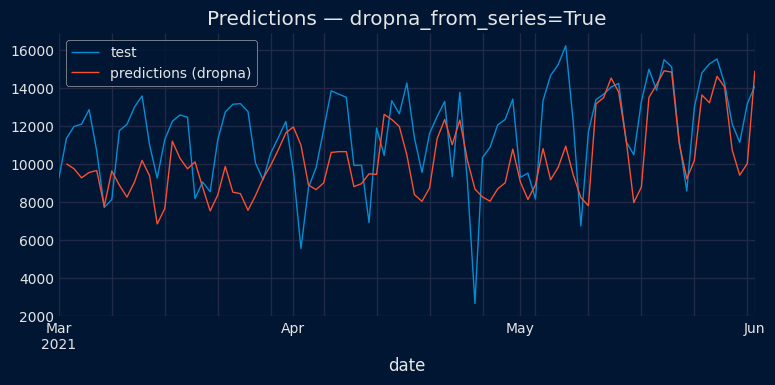

In [12]:
# Plot predictions
# ==============================================================================
fig, ax = plt.subplots(figsize=(8, 3.5))
data_test['users'].plot(ax=ax, label='test', linewidth=1)
predictions_dropna['pred'].plot(ax=ax, label='predictions (dropna)', linewidth=1)
ax.set_title('Predictions — dropna_from_series=True')
ax.legend();

## Option 3: Imputation + Weighted forecasting

A complementary strategy is to **impute** the missing values (e.g., using interpolation) and then **down-weight** the imputed observations during training using the `weight_func` parameter. This way, the model uses all available data but gives less importance to the imputed values.

This approach is particularly useful when:

- You want to use **all** observations (including those near the gaps) rather than discarding them.
- The estimator does **not** support `NaN` values natively.
- The gaps are large and dropping rows would leave too little training data.

A detailed example of this strategy is available in the FAQ: [Forecasting time series with missing values](../faq/forecasting-time-series-with-missing-values.ipynb).

## Comparison of strategies

In [13]:
# Comparison table
# ==============================================================================
comparison = pd.DataFrame({
    'Strategy': [
        'dropna_from_series=True (LightGBM)',
        'NaN-tolerant estimator: LightGBM (dropna=False)',
        'NaN-tolerant estimator: HistGradientBoosting (dropna=False)',
    ],
    'MAE': [
        metric_dropna.at[0, 'mean_absolute_error'],
        metric_lgbm.at[0, 'mean_absolute_error'],
        metric_hgbr.at[0, 'mean_absolute_error'],
    ]
})

comparison.sort_values('MAE').style.format({'MAE': '{:.2f}'}).hide(axis='index')

Strategy,MAE
dropna_from_series=True (LightGBM),2088.15
NaN-tolerant estimator: LightGBM (dropna=False),2733.24
NaN-tolerant estimator: HistGradientBoosting (dropna=False),2785.25


## Recommendations

| Scenario | Recommended strategy |
|:---------|:---------------------|
| Using LightGBM, CatBoost, XGBoost (hist), or HistGradientBoosting | `dropna_from_series=False` (Option 1) — let the estimator handle NaNs. No data loss. |
| Estimator does not support NaN (RandomForest, LinearRegression, SVR...) | `dropna_from_series=True` (Option 2) — drop incomplete rows before fitting. |
| Few or small gaps in the series | `dropna_from_series=True` (Option 2) — simple and the data loss is negligible. |
| Large gaps, need to preserve all training data | Imputation + `weight_func` (Option 3) — see the [FAQ guide](../faq/forecasting-time-series-with-missing-values.ipynb). |
| Estimator does not support NaN and gaps are large | Imputation + `weight_func` (Option 3) — necessary to fill NaNs before training. |
| Multi-series with different lengths | `ForecasterRecursiveMultiSeries` with `dropna_from_series=True`. |

If you are using a NaN-tolerant estimator such as LightGBM, keeping `dropna_from_series=False` (the default) is the recommended approach. The model retains all training samples and learns to handle the missingness pattern internally. Use `dropna_from_series=True` as the universal fallback when the estimator cannot handle NaN values, or when you want to ensure the model only sees complete observations.